[3blue1brown - chapter 1 - vectors]: https://youtu.be/fNk_zzaMoSs?si=XpUdKfwcpQXDHe5I

# [Chapter 1: Abstract Vector Spaces](https://youtu.be/fNk_zzaMoSs?si=TYciUFCIPXQoiV88)

## 1. What is a Vector?

There are three ways to think about vectors, each useful in different contexts:

### Physics Perspective: Arrows in Space
- A vector is an **arrow** with:
  - **Length** (magnitude)
  - **Direction**
- Can move it anywhere (as long as length and direction stay the same)
- Examples: velocity, force, displacement

### Computer Science Perspective: Ordered Lists
- A vector is a **list of numbers**
- Order matters: `[3, 2]` ≠ `[2, 3]`
- 2D vector: two numbers
- 3D vector: three numbers
- Examples: features in machine learning, pixel coordinates

### Mathematics Perspective: Abstract Objects
- A vector can be **anything** where you can:
  - Add two vectors
  - Multiply by a number (scalar)
- Examples: functions, polynomials, matrices

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 8)
np.set_printoptions(precision=3, suppress=True)

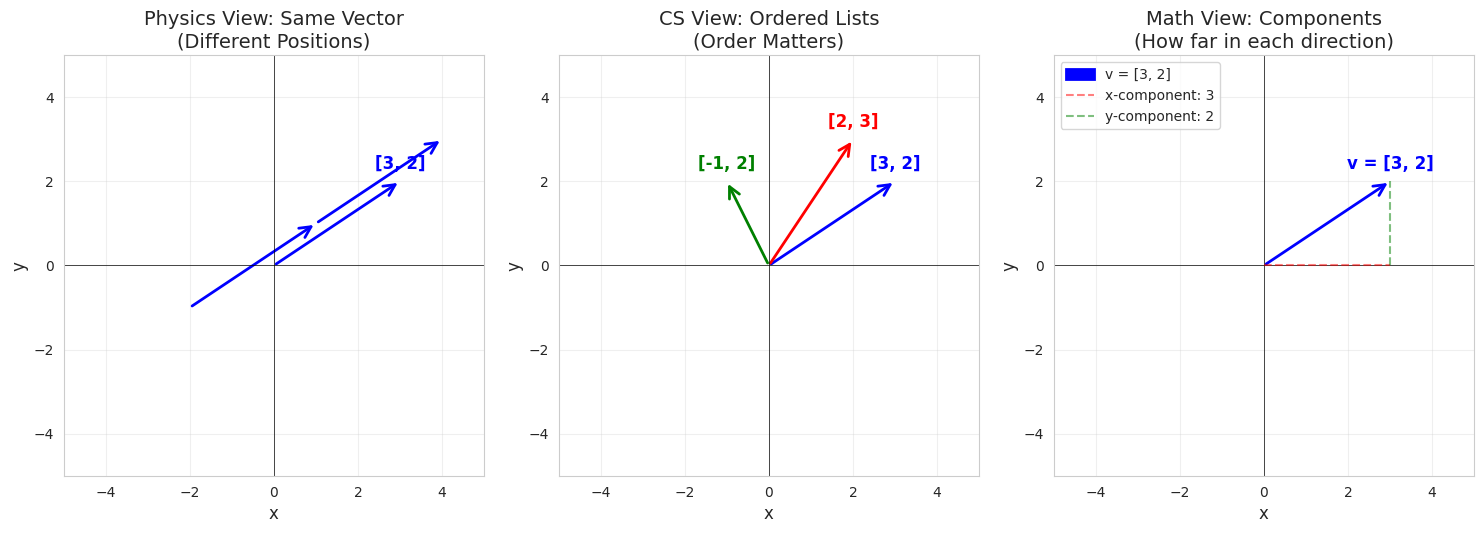

Key Insight: In linear algebra, we think of vectors as ROOTED AT THE ORIGIN.
The vector [3, 2] means: go 3 units right, 2 units up from the origin.


In [27]:
def draw_vector(ax, start, end, color='blue', label='', width=0.01):
    """Draw a vector as an arrow from start to end"""
    arrow = FancyArrowPatch(
        start, end,
        arrowstyle='->', 
        mutation_scale=20,
        linewidth=2,
        color=color,
        label=label
    )
    ax.add_patch(arrow)
    
    # Add coordinates label at the tip
    if label:
        ax.text(end[0], end[1] + 0.3, label, 
               fontsize=12, ha='center', color=color, fontweight='bold')

def setup_2d_plot(ax, xlim=(-5, 5), ylim=(-5, 5)):
    """Setup a 2D coordinate system"""
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('y', fontsize=12)

# Example: Visualizing vectors
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Same vector at different positions (physics view)
v = np.array([3, 2])
setup_2d_plot(axes[0])
draw_vector(axes[0], [0, 0], v, 'blue', '[3, 2]')
draw_vector(axes[0], [1, 1], [1, 1] + v, 'blue', '')
draw_vector(axes[0], [-2, -1], [-2, -1] + v, 'blue', '')
axes[0].set_title('Physics View: Same Vector\n(Different Positions)', fontsize=14)

# Different 2D vectors (CS view)
setup_2d_plot(axes[1])
draw_vector(axes[1], [0, 0], [3, 2], 'blue', '[3, 2]')
draw_vector(axes[1], [0, 0], [2, 3], 'red', '[2, 3]')
draw_vector(axes[1], [0, 0], [-1, 2], 'green', '[-1, 2]')
axes[1].set_title('CS View: Ordered Lists\n(Order Matters)', fontsize=14)

# Vector with coordinates
setup_2d_plot(axes[2])
v = np.array([3, 2])
draw_vector(axes[2], [0, 0], v, 'blue', 'v = [3, 2]')
# Draw components
axes[2].plot([0, v[0]], [0, 0], 'r--', alpha=0.5, linewidth=1.5, label='x-component: 3')
axes[2].plot([v[0], v[0]], [0, v[1]], 'g--', alpha=0.5, linewidth=1.5, label='y-component: 2')
axes[2].legend(loc='upper left')
axes[2].set_title('Math View: Components\n(How far in each direction)', fontsize=14)

plt.tight_layout()
plt.show()

print("Key Insight: In linear algebra, we think of vectors as ROOTED AT THE ORIGIN.")
print("The vector [3, 2] means: go 3 units right, 2 units up from the origin.")

## 2. Vector Addition

### Geometric View
To add vectors **v** and **w**:
1. Place the tail of **w** at the tip of **v**
2. Draw from origin to the tip of **w**
3. That's **v + w**!

### Numerical View
Just add corresponding components:
$$\begin{bmatrix} v_1 \\ v_2 \end{bmatrix} + \begin{bmatrix} w_1 \\ w_2 \end{bmatrix} = \begin{bmatrix} v_1 + w_1 \\ v_2 + w_2 \end{bmatrix}$$

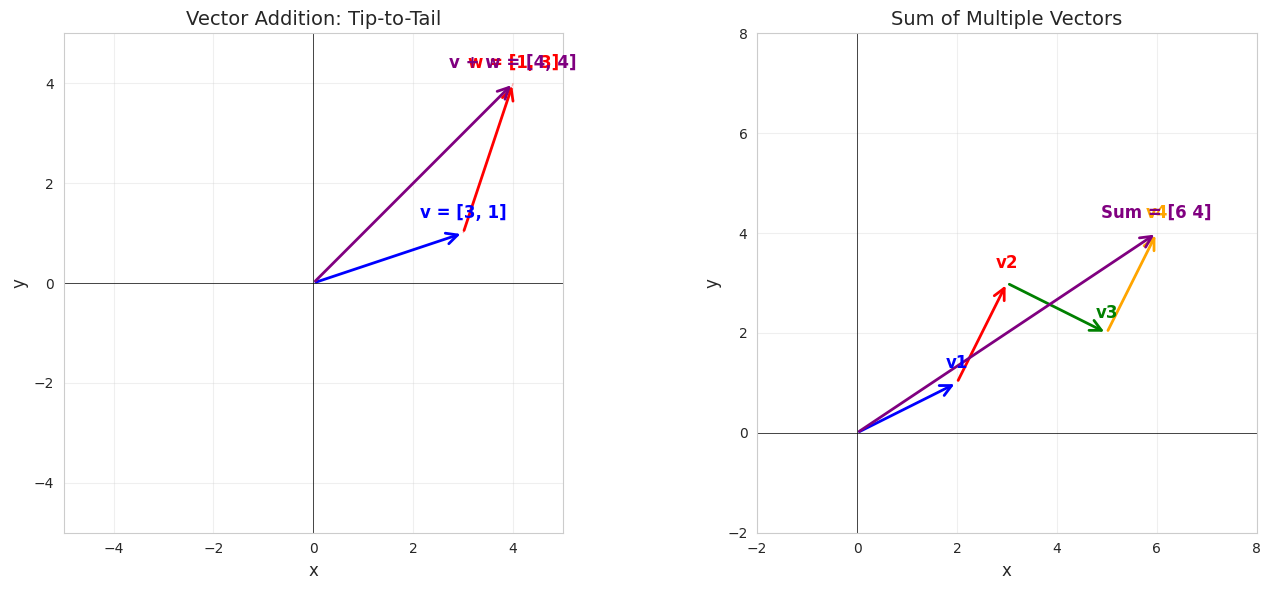


Vector Addition (Componentwise):
v = [3 1]
w = [1 3]
v + w = [4 4]

Interpretation: Start at origin, walk v, then walk w. Where are you?


In [28]:
# Vector addition visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

v = np.array([3, 1])
w = np.array([1, 3])
v_plus_w = v + w

# Left: Step-by-step addition
setup_2d_plot(axes[0])
draw_vector(axes[0], [0, 0], v, 'blue', 'v = [3, 1]')
draw_vector(axes[0], v, v_plus_w, 'red', 'w = [1, 3]')
draw_vector(axes[0], [0, 0], v_plus_w, 'purple', 'v + w = [4, 4]')
axes[0].plot([v[0], v_plus_w[0]], [v[1], v_plus_w[1]], 'r--', alpha=0.3, linewidth=1)
axes[0].set_title('Vector Addition: Tip-to-Tail', fontsize=14)

# Right: Multiple vectors forming a path
setup_2d_plot(axes[1], xlim=(-2, 8), ylim=(-2, 8))
vectors = [
    np.array([2, 1]),
    np.array([1, 2]),
    np.array([2, -1]),
    np.array([1, 2])
]
colors = ['blue', 'red', 'green', 'orange']
current_pos = np.array([0, 0])

for i, (vec, color) in enumerate(zip(vectors, colors)):
    next_pos = current_pos + vec
    draw_vector(axes[1], current_pos, next_pos, color, f'v{i+1}')
    current_pos = next_pos

# Draw the sum
total = sum(vectors)
draw_vector(axes[1], [0, 0], total, 'purple', f'Sum = {total}', width=0.015)
axes[1].set_title('Sum of Multiple Vectors', fontsize=14)

plt.tight_layout()
plt.show()

print("\nVector Addition (Componentwise):")
print(f"v = {v}")
print(f"w = {w}")
print(f"v + w = {v_plus_w}")
print(f"\nInterpretation: Start at origin, walk v, then walk w. Where are you?")

## 3. Scalar Multiplication

### Geometric View
Multiplying a vector by a **scalar** (number):
- Stretches or squishes the vector
- If scalar > 1: **stretch**
- If 0 < scalar < 1: **shrink**
- If scalar < 0: **reverse direction**

### Numerical View
$$c \cdot \begin{bmatrix} v_1 \\ v_2 \end{bmatrix} = \begin{bmatrix} c \cdot v_1 \\ c \cdot v_2 \end{bmatrix}$$

/tmp/ipython-input-1384971246.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('RdYlBu')(np.linspace(0, 1, len(scalars)))


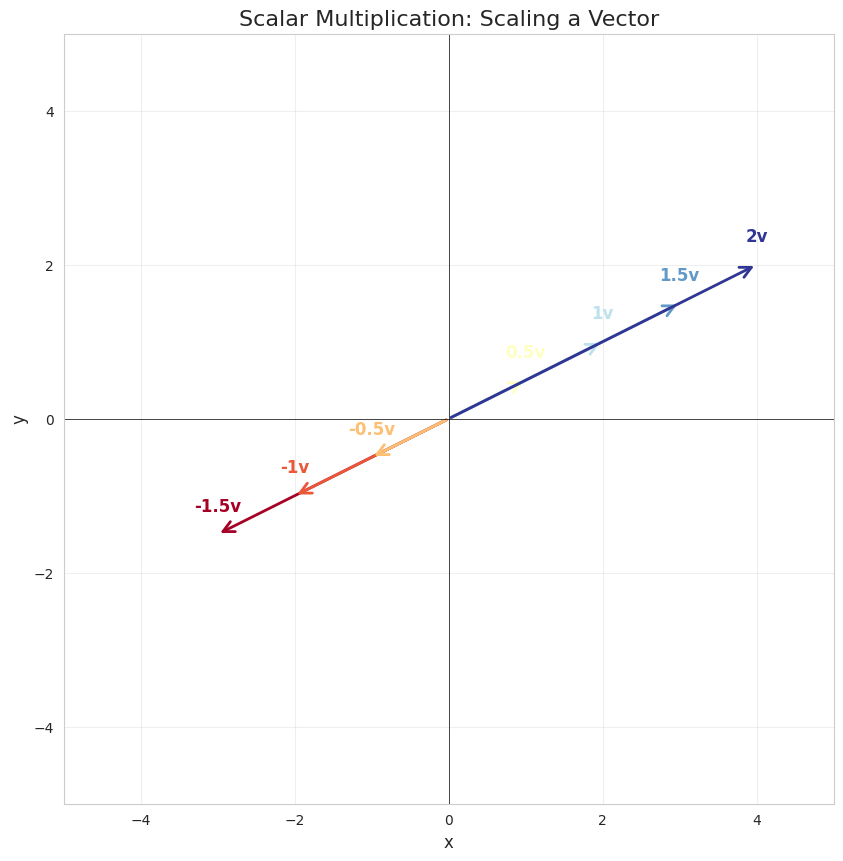

Scalar Multiplication Examples:
Original vector v = [2 1]
2v = [4 2]  (doubled)
0.5v = [1.  0.5]  (halved)
-1v = [-2 -1]  (reversed)


In [29]:
# Scalar multiplication
fig, ax = plt.subplots(figsize=(10, 10))
setup_2d_plot(ax, xlim=(-5, 5), ylim=(-5, 5))

v = np.array([2, 1])
scalars = [-1.5, -1, -0.5, 0.5, 1, 1.5, 2]
colors = plt.cm.get_cmap('RdYlBu')(np.linspace(0, 1, len(scalars)))

for scalar, color in zip(scalars, colors):
    scaled_v = scalar * v
    draw_vector(ax, [0, 0], scaled_v, color, f'{scalar}v')

ax.set_title('Scalar Multiplication: Scaling a Vector', fontsize=16)
plt.show()

print("Scalar Multiplication Examples:")
print(f"Original vector v = {v}")
print(f"2v = {2*v}  (doubled)")
print(f"0.5v = {0.5*v}  (halved)")
print(f"-1v = {-1*v}  (reversed)")

## 4. Linear Combinations

A **linear combination** of vectors is:
$$a\mathbf{v} + b\mathbf{w}$$

where $a$ and $b$ are scalars.

### Key Question: What points can you reach?

Given two vectors **v** and **w**, what points can you reach by choosing different values of $a$ and $b$ in $a\mathbf{v} + b\mathbf{w}$?

This is called the **span** of **v** and **w**.

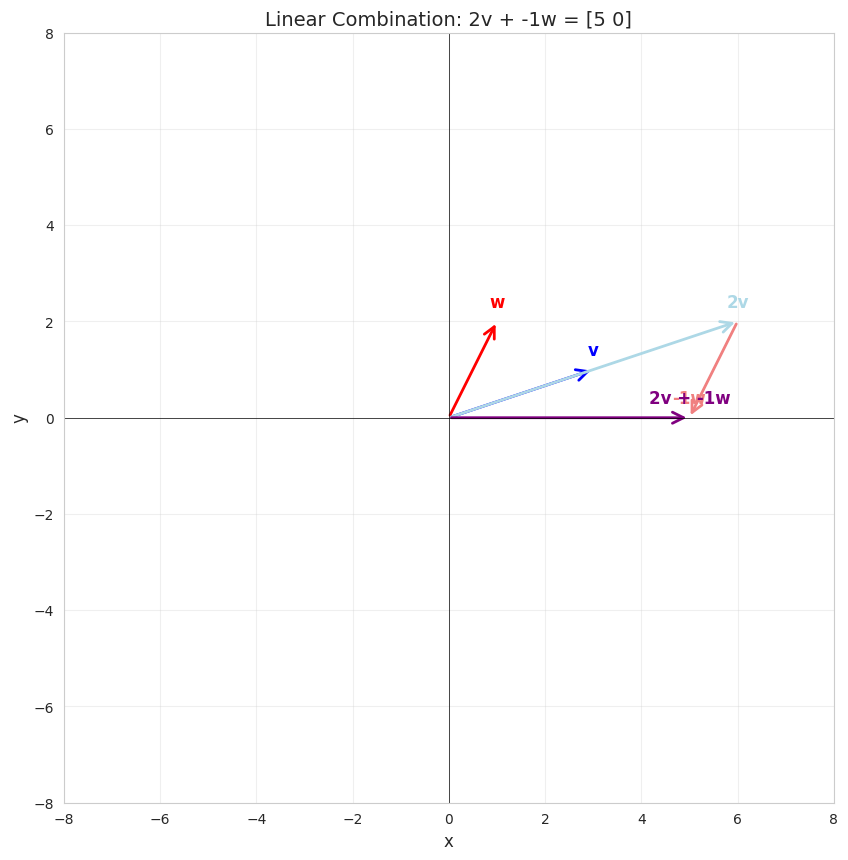


2v + (-1)w = [5 0]


In [30]:
# Interactive linear combinations
def plot_linear_combination(v, w, a, b):
    """Plot a linear combination av + bw"""
    fig, ax = plt.subplots(figsize=(10, 10))
    setup_2d_plot(ax, xlim=(-8, 8), ylim=(-8, 8))
    
    # Draw basis vectors
    draw_vector(ax, [0, 0], v, 'blue', 'v')
    draw_vector(ax, [0, 0], w, 'red', 'w')
    
    # Draw scaled vectors
    av = a * v
    bw = b * w
    draw_vector(ax, [0, 0], av, 'lightblue', f'{a}v')
    draw_vector(ax, av, av + bw, 'lightcoral', f'{b}w')
    
    # Draw result
    result = av + bw
    draw_vector(ax, [0, 0], result, 'purple', f'{a}v + {b}w', width=0.015)
    
    ax.set_title(f'Linear Combination: {a}v + {b}w = {result}', fontsize=14)
    plt.show()
    
    return result

# Example
v = np.array([3, 1])
w = np.array([1, 2])

result = plot_linear_combination(v, w, a=2, b=-1)
print(f"\n2v + (-1)w = {result}")

Case 1: Two INDEPENDENT vectors
v = [3 1], w = [1 2]


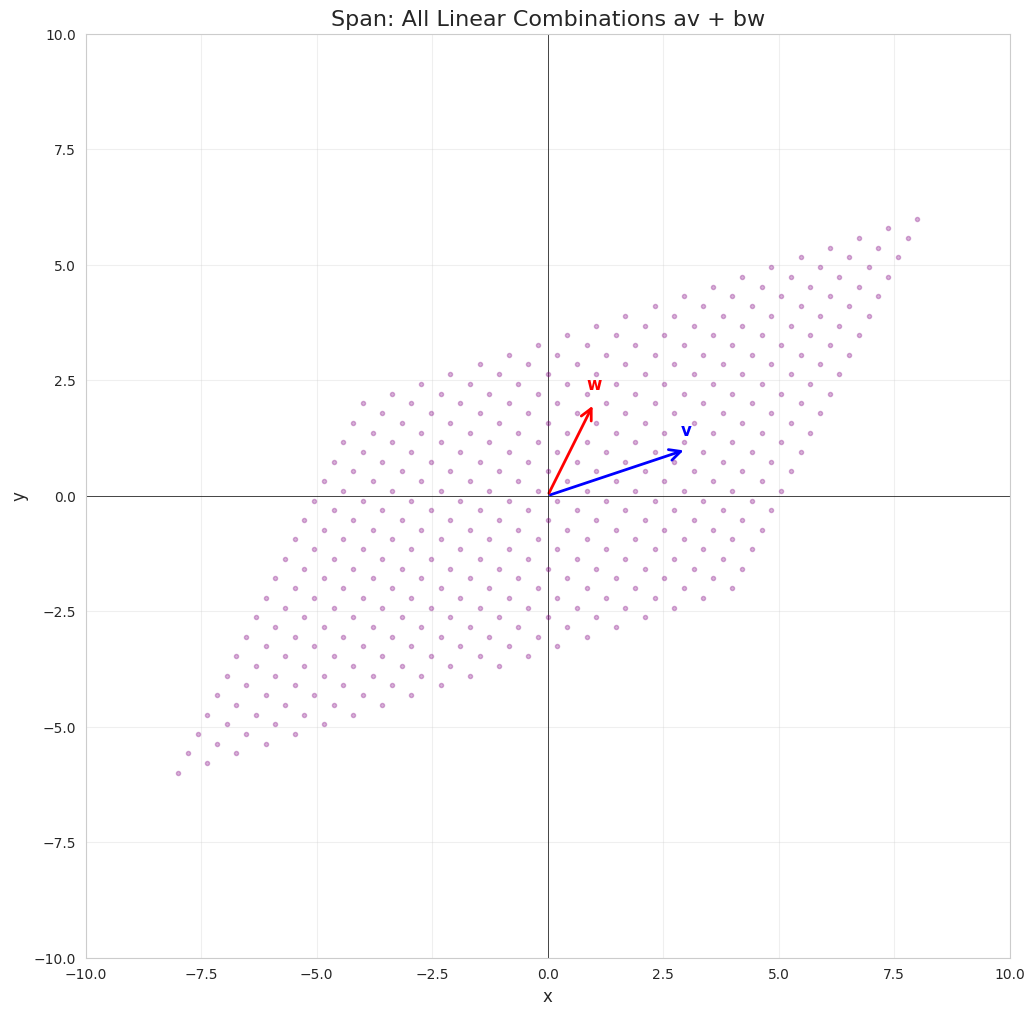

Span = ALL of 2D space (the entire plane)



In [31]:
# Visualize the SPAN of two vectors
def visualize_span(v, w, n_samples=20):
    """Visualize all possible linear combinations"""
    fig, ax = plt.subplots(figsize=(12, 12))
    setup_2d_plot(ax, xlim=(-10, 10), ylim=(-10, 10))
    
    # Generate many linear combinations
    scalars = np.linspace(-2, 2, n_samples)
    
    # Draw grid of linear combinations
    for a in scalars:
        for b in scalars:
            point = a * v + b * w
            ax.plot(point[0], point[1], 'o', color='purple', alpha=0.3, markersize=3)
    
    # Draw the two vectors
    draw_vector(ax, [0, 0], v, 'blue', 'v', width=0.015)
    draw_vector(ax, [0, 0], w, 'red', 'w', width=0.015)
    
    ax.set_title('Span: All Linear Combinations av + bw', fontsize=16)
    plt.show()

# Case 1: Two independent vectors (span = all of 2D space)
v = np.array([3, 1])
w = np.array([1, 2])
print("Case 1: Two INDEPENDENT vectors")
print(f"v = {v}, w = {w}")
visualize_span(v, w)
print("Span = ALL of 2D space (the entire plane)\n")

Case 2: Two COLLINEAR vectors (one is a multiple of the other)
v = [2 1], w = [4 2]
Notice: w = 2v



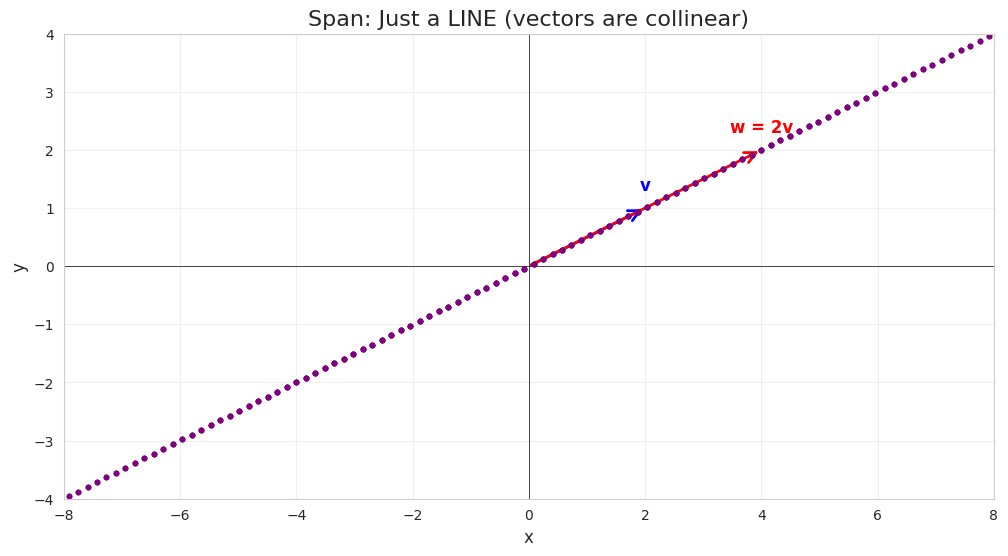

Span = A LINE through the origin
Why? Because w doesn't add any new direction!


In [32]:
# Case 2: Two collinear vectors (span = a line)
v = np.array([2, 1])
w = np.array([4, 2])  # w = 2v (on same line)

print("Case 2: Two COLLINEAR vectors (one is a multiple of the other)")
print(f"v = {v}, w = {w}")
print(f"Notice: w = 2v\n")

fig, ax = plt.subplots(figsize=(12, 8))
setup_2d_plot(ax, xlim=(-8, 8), ylim=(-4, 4))

# Generate linear combinations
scalars = np.linspace(-2, 2, 50)
for a in scalars:
    for b in scalars:
        point = a * v + b * w
        ax.plot(point[0], point[1], 'o', color='purple', alpha=0.3, markersize=3)

draw_vector(ax, [0, 0], v, 'blue', 'v', width=0.015)
draw_vector(ax, [0, 0], w, 'red', 'w = 2v', width=0.015)

ax.set_title('Span: Just a LINE (vectors are collinear)', fontsize=16)
plt.show()

print("Span = A LINE through the origin")
print("Why? Because w doesn't add any new direction!")

## 5. Basis Vectors

### Definition
The **basis** of a vector space is a set of vectors that:
1. **Span** the entire space
2. Are **linearly independent** (none is a combination of others)

### Standard Basis in 2D
$$\hat{i} = \begin{bmatrix} 1 \\ 0 \end{bmatrix}, \quad \hat{j} = \begin{bmatrix} 0 \\ 1 \end{bmatrix}$$

### Key Insight
When you write $\begin{bmatrix} 3 \\ 2 \end{bmatrix}$, you really mean:
$$3\hat{i} + 2\hat{j} = 3\begin{bmatrix} 1 \\ 0 \end{bmatrix} + 2\begin{bmatrix} 0 \\ 1 \end{bmatrix}$$

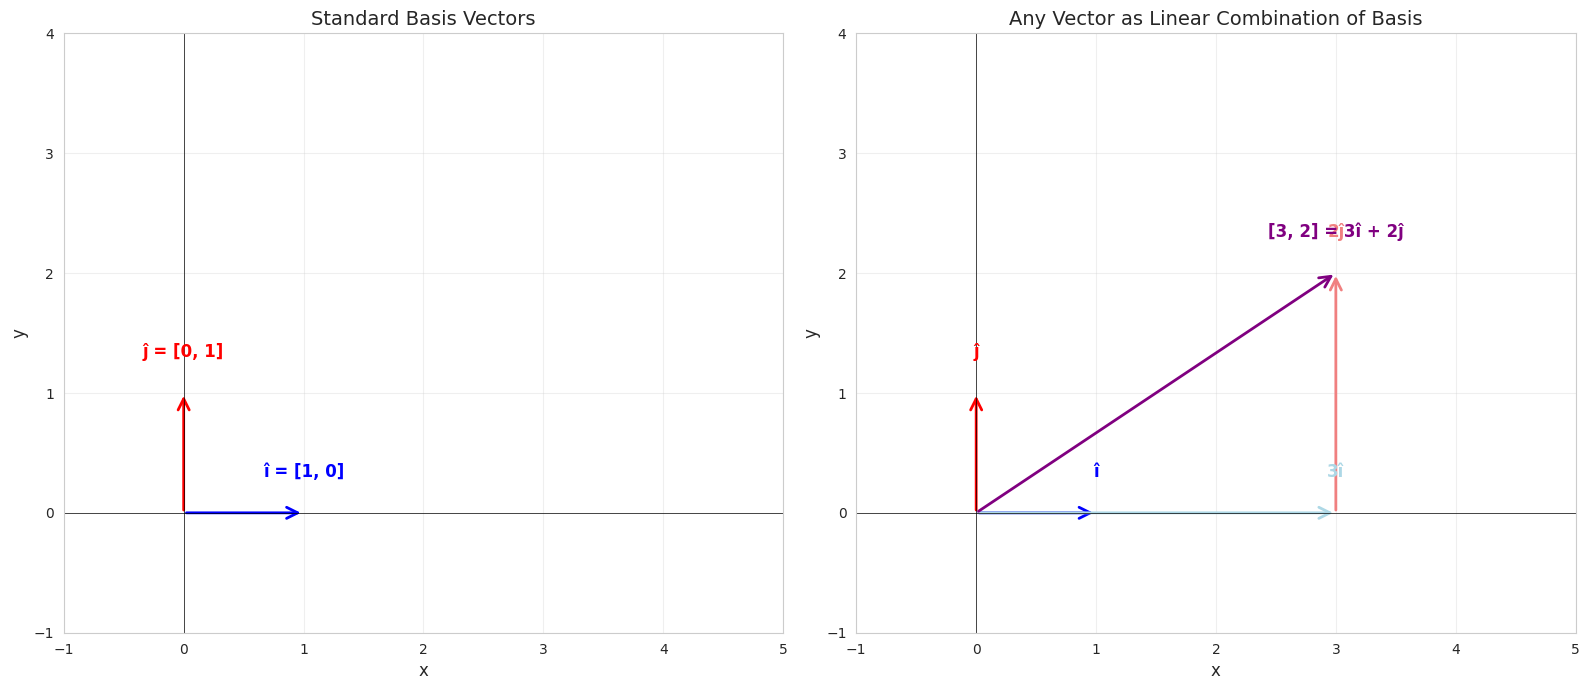

Every 2D vector can be written as: v = aî + bĵ
The numbers [a, b] are called the COORDINATES of v

Coordinates depend on choice of basis!


In [33]:
# Standard basis vectors
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Show basis vectors
setup_2d_plot(axes[0], xlim=(-1, 5), ylim=(-1, 4))
i_hat = np.array([1, 0])
j_hat = np.array([0, 1])

draw_vector(axes[0], [0, 0], i_hat, 'blue', 'î = [1, 0]')
draw_vector(axes[0], [0, 0], j_hat, 'red', 'ĵ = [0, 1]')
axes[0].set_title('Standard Basis Vectors', fontsize=14)

# Right: Show any vector as linear combination of basis
setup_2d_plot(axes[1], xlim=(-1, 5), ylim=(-1, 4))
v = np.array([3, 2])

draw_vector(axes[1], [0, 0], i_hat, 'blue', 'î', width=0.01)
draw_vector(axes[1], [0, 0], j_hat, 'red', 'ĵ', width=0.01)

# Show 3*i_hat
draw_vector(axes[1], [0, 0], 3*i_hat, 'lightblue', '3î')
# Show 2*j_hat starting from tip of 3*i_hat
draw_vector(axes[1], 3*i_hat, v, 'lightcoral', '2ĵ')
# Show result
draw_vector(axes[1], [0, 0], v, 'purple', '[3, 2] = 3î + 2ĵ', width=0.015)

axes[1].set_title('Any Vector as Linear Combination of Basis', fontsize=14)

plt.tight_layout()
plt.show()

print("Every 2D vector can be written as: v = aî + bĵ")
print("The numbers [a, b] are called the COORDINATES of v")
print("\nCoordinates depend on choice of basis!")

## 6. Linear Dependence vs Independence

### Linearly Dependent
Vectors are **linearly dependent** if one can be written as a linear combination of others.

Example: $\mathbf{w} = 2\mathbf{v}$ → dependent

### Linearly Independent
Vectors are **linearly independent** if none can be written as a combination of others.

Example: $\begin{bmatrix} 1 \\ 0 \end{bmatrix}$ and $\begin{bmatrix} 0 \\ 1 \end{bmatrix}$ → independent

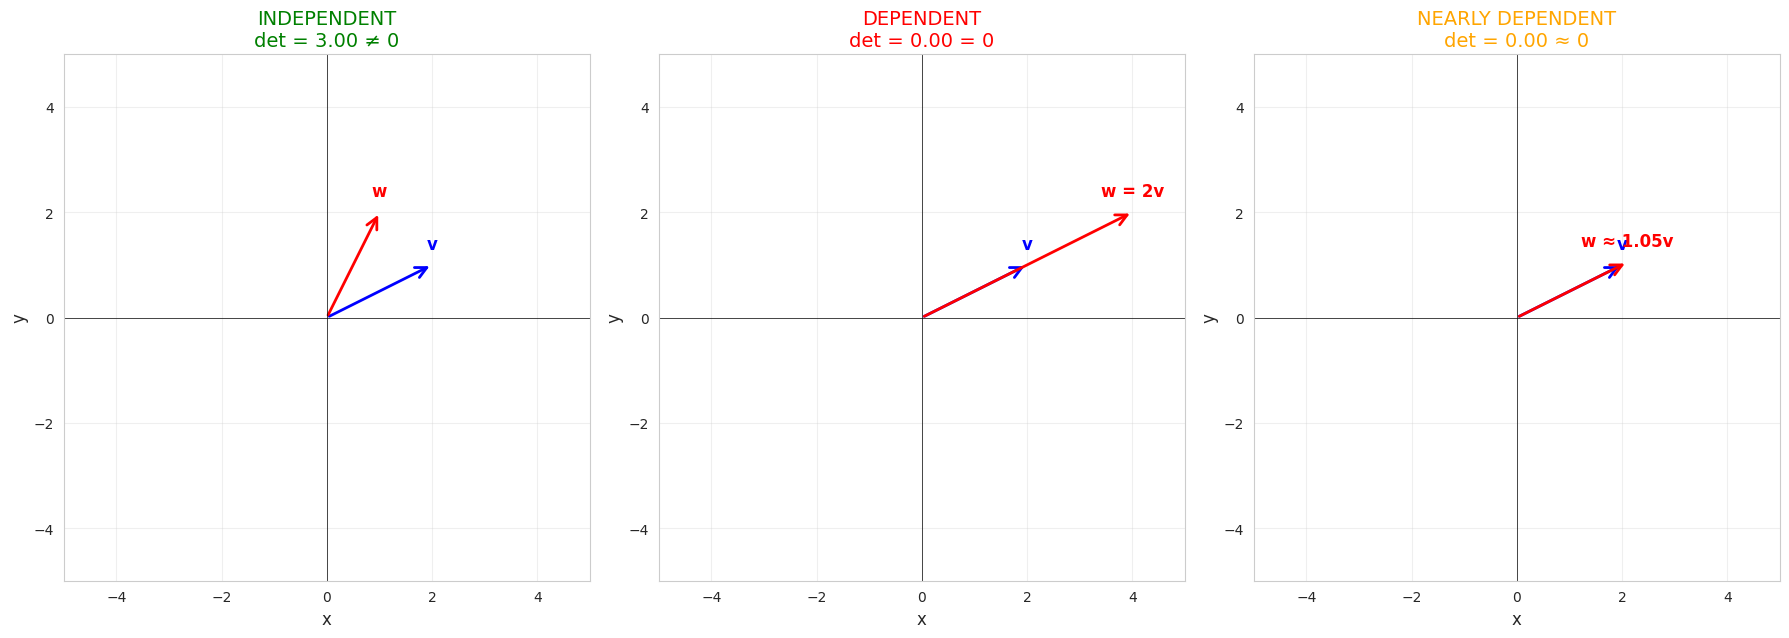

Linear Independence Test (2D):
Two vectors are independent if det(v, w) ≠ 0

Geometrically: Independent if they point in different directions!


In [34]:
# Linear independence check
def check_linear_independence(v, w):
    """Check if two 2D vectors are linearly independent"""
    # Two 2D vectors are independent if their determinant is non-zero
    det = v[0]*w[1] - v[1]*w[0]
    return abs(det) > 1e-10, det

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Case 1: Independent
v1 = np.array([2, 1])
w1 = np.array([1, 2])
setup_2d_plot(axes[0])
draw_vector(axes[0], [0, 0], v1, 'blue', 'v')
draw_vector(axes[0], [0, 0], w1, 'red', 'w')
indep1, det1 = check_linear_independence(v1, w1)
axes[0].set_title(f'INDEPENDENT\ndet = {det1:.2f} ≠ 0', fontsize=14, color='green')

# Case 2: Dependent (collinear)
v2 = np.array([2, 1])
w2 = np.array([4, 2])
setup_2d_plot(axes[1])
draw_vector(axes[1], [0, 0], v2, 'blue', 'v')
draw_vector(axes[1], [0, 0], w2, 'red', 'w = 2v')
indep2, det2 = check_linear_independence(v2, w2)
axes[1].set_title(f'DEPENDENT\ndet = {det2:.2f} = 0', fontsize=14, color='red')

# Case 3: Nearly dependent
v3 = np.array([2, 1])
w3 = np.array([2.1, 1.05])
setup_2d_plot(axes[2])
draw_vector(axes[2], [0, 0], v3, 'blue', 'v')
draw_vector(axes[2], [0, 0], w3, 'red', 'w ≈ 1.05v')
indep3, det3 = check_linear_independence(v3, w3)
axes[2].set_title(f'NEARLY DEPENDENT\ndet = {det3:.2f} ≈ 0', fontsize=14, color='orange')

plt.tight_layout()
plt.show()

print("Linear Independence Test (2D):")
print("Two vectors are independent if det(v, w) ≠ 0")
print("\nGeometrically: Independent if they point in different directions!")

## Summary

### Key Concepts

1. **Vectors** = arrows in space (magnitude + direction)
2. **Vector addition** = tip-to-tail method
3. **Scalar multiplication** = stretch/shrink/flip
4. **Linear combination** = $a\mathbf{v} + b\mathbf{w}$ (scaled and added)
5. **Span** = all possible linear combinations
6. **Basis** = independent vectors that span the space
7. **Coordinates** = coefficients in basis representation

### Geometric Intuition

- Think of vectors as **movements** in space
- Addition = **chain movements** together
- Scalar multiplication = **scale** the movement
- Basis vectors = **fundamental directions**
- Coordinates = "**recipe**" for reaching a point

### Next Steps

Now that we understand vectors, we're ready to see how **linear transformations** move vectors around!

## Exercises

1. Draw the vector [2, 3] and express it as a linear combination of î and ĵ
2. Find three different ways to express [6, 3] as a linear combination of [2, 1] and [1, 1]
3. Can you write [5, 7] as a linear combination of [1, 2] and [2, 4]? Why or why not?
4. Prove that î and ĵ are linearly independent
5. Find the span of [1, 2] and [3, 6]